<a href="https://colab.research.google.com/github/swirita/Cirrhosis-Prediction/blob/main/Cirrhosis_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cirrhosis Prediction
- Author: Siwar Ehwass

## Overview

### Data Dictionary

| Feature | Description |
|---------|-------------|
| **ID** | Unique identifier for each patient. |
| **N_Days** | Number of days between registration and the earlier of death, liver transplantation, or the end of the study (July 1986). |
| **Status** | Patient outcome: **C** = censored, **CL** = censored due to liver transplant, **D** = death. *(Target Variable)*.|
| **Drug** | Treatment received: **D-penicillamine** or **Placebo**. |
| **Age** | Patient age in **days**. |
| **Sex** | Patient gender: **M** = Male, **F** = Female. |
| **Ascites** | Presence of ascites: **Y** = Yes, **N** = No. |
| **Hepatomegaly** | Presence of enlarged liver: **Y** = Yes, **N** = No. |
| **Spiders** | Presence of spider angiomas: **Y** = Yes, **N** = No. |
| **Edema** | Edema status: **N** = No edema, **S** = Edema controlled with diuretics, **Y** = Edema despite diuretic therapy. |
| **Bilirubin** | Serum bilirubin level (mg/dL). |
| **Cholesterol** | Serum cholesterol level (mg/dL). |
| **Albumin** | Serum albumin level (g/dL). |
| **Copper** | Urine copper level (µg/day). |
| **Alk_Phos** | Alkaline phosphatase level (U/L). |
| **SGOT** | Serum glutamic-oxaloacetic transaminase (SGOT) level (U/mL). |
| **Triglycerides** | Serum triglyceride level (mg/dL). |
| **Platelets** | Platelet count (thousands per mL). |
| **Prothrombin** | Prothrombin time (seconds). |
| **Stage** | Histologic stage of liver disease (**1**, **2**, **3**, or **4**)  |

###  Dataset Overview

> ### Target
>
> - We need to use 17 (clinical) features to predict survival of patient with liver
> - 3 classes : 0 = D (death), 1 = C (censored), 2 = CL (censored due to liver transplantation)
>
> - Each row represents **one patient** and their medical information.
>
> ### Features
>
> The dataset contains **20 columns** in total. Excluding the target (`Status`), there are **19 features**. The `ID` column can also be removed since it is only an identifier and does not contribute to prediction.
>
> ### Number of Rows
>
> The dataset contains **424 rows**.
>
> ### Opportunities for Feature Selection
>
> - Remove the `ID` column because it has no predictive value.
> - Use feature selection techniques such as **Random Forest Feature Importance**, **Forward Selection**, or **Premutation Importance** to identify the most important features.
> - Apply **Principal Component Analysis (PCA)** to reduce dimensionality while retaining most of the dataset's information.
>
> ### Expected Challenges
>
> - Missing values in several features require imputation.
> - The dataset is relatively small, increasing the possibility of overfitting.
> - The target classes are imbalanced, which may affect prediction performance.
> - The dataset contains both categorical and numerical features that require different preprocessing techniques.

## Imports

In [264]:
# Download Data from Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/cirrhosis-prediction-dataset")

print("Path to dataset files:", path)

import os
print(os.listdir("/kaggle/input/cirrhosis-prediction-dataset"))

Using Colab cache for faster access to the 'cirrhosis-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/cirrhosis-prediction-dataset
['cirrhosis.csv']


In [265]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import SelectFromModel


from sklearn import set_config
set_config(transform_output='pandas')

## Load and Inspect Data

In [266]:
# create dataframe
df = pd.read_csv("/kaggle/input/cirrhosis-prediction-dataset/cirrhosis.csv")
# check information about df
df.info()
# check first 5 rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


> What we can interpret from this:
>  1) We have 418 rows, and 20 columns. A small dataset.
>  2) `ID` us just an identifier, it does not help with model training.
>  3) There is null values in `Drug` & `Copper` and multipile other features.
>  4) `Edema`, `Stage` is an Ordinal Feature.

## Clean Data

### Dropping ID

In [267]:
df= df.drop(columns=['ID'])

### Duplicated Rows

In [268]:
# check for duplicated data
df.duplicated().sum()

np.int64(0)

- there are no duplicated values



### Unique Identifiers

In [269]:
# check for unique percentage
df.nunique() / len(df) * 100

,0
N_Days,95.454545
Status,0.717703
Drug,0.478469
Age,82.296651
Sex,0.478469
Ascites,0.478469
Hepatomegaly,0.478469
Spiders,0.478469
Edema,0.717703
Bilirubin,23.444976


> **Notes:**
> - `N_Days` and `Age` have a high percentage of unique values, which is expected since they are continuous variables. They provide useful information and should be retained.
>
> - Most categorical features (`Drug`, `Sex`, `Ascites`, `Hepatomegaly`, and `Spiders`) have very low uniqueness because they contain only a few categories, which is normal for categorical data.
>
> - `Status`, `Edema`, and `Stage` also have low unique percentages because they contain only a small number of predefined classes.
>
> - Laboratory measurements such as `Bilirubin`, `Cholesterol`, `Albumin`, `Copper`, `Alk_Phos`, `SGOT`, `Triglycerides`, `Platelets`, and `Prothrombin` show moderate to high uniqueness, indicating they are continuous features with a good range of values.
>
> - Overall, there are **no high-cardinality categorical features**, so categorical encoding should be straightforward. The continuous features also show sufficient variation, making them useful for model training.

### Data Inconsistencies
- There is no data inconsistencies

In [270]:
# filter out both num and object features
num_cols=df.select_dtypes('number').columns # select numbers
cat_cols=df.select_dtypes('object').columns # select objects

# loop through each one's value counts (objects)
for col in cat_cols:
    print(f'Value counts of {col}:\n {df[col].value_counts(dropna=False)} \n')

Value counts of Status:
 Status
C     232
D     161
CL     25
Name: count, dtype: int64 

Value counts of Drug:
 Drug
D-penicillamine    158
Placebo            154
NaN                106
Name: count, dtype: int64 

Value counts of Sex:
 Sex
F    374
M     44
Name: count, dtype: int64 

Value counts of Ascites:
 Ascites
N      288
NaN    106
Y       24
Name: count, dtype: int64 

Value counts of Hepatomegaly:
 Hepatomegaly
Y      160
N      152
NaN    106
Name: count, dtype: int64 

Value counts of Spiders:
 Spiders
N      222
NaN    106
Y       90
Name: count, dtype: int64 

Value counts of Edema:
 Edema
N    354
S     44
Y     20
Name: count, dtype: int64 



> What we can get from this:
> 1) For `Drug` feature:
>     - Missing features -> impute with most frequent or new constant 'MISSING'
>     - It has 106 null values.
> 2) For `Hepatomegaly` Feature:
>     - It has 106 null values.
> 3) For `Spiders` Feature:
>     - It has 106 null values.
>     - Missing features -> impute with most frequent or new constant 'MISSING'
> 4) For `Edema` Feature:
>     - It is an Ordinal Feature ( N < S < Y).


In [271]:
# check describe for numbers (loop)
for col in num_cols:
    print(f'Describe for {col}\n {df[col].describe()}')

Describe for N_Days
 count     418.000000
mean     1917.782297
std      1104.672992
min        41.000000
25%      1092.750000
50%      1730.000000
75%      2613.500000
max      4795.000000
Name: N_Days, dtype: float64
Describe for Age
 count      418.000000
mean     18533.351675
std       3815.845055
min       9598.000000
25%      15644.500000
50%      18628.000000
75%      21272.500000
max      28650.000000
Name: Age, dtype: float64
Describe for Bilirubin
 count    418.000000
mean       3.220813
std        4.407506
min        0.300000
25%        0.800000
50%        1.400000
75%        3.400000
max       28.000000
Name: Bilirubin, dtype: float64
Describe for Cholesterol
 count     284.000000
mean      369.510563
std       231.944545
min       120.000000
25%       249.500000
50%       309.500000
75%       400.000000
max      1775.000000
Name: Cholesterol, dtype: float64
Describe for Albumin
 count    418.000000
mean       3.497440
std        0.424972
min        1.960000
25%        3.242

> **Notes:**
> - Most numerical features have a wide range of values, which is expected for medical measurements. Features such as `Age`, `N_Days`, `Bilirubin`, `Copper`, `Alk_Phos`, `SGOT`, and `Platelets` show good variability and are likely to provide useful information for the model.
>
> - Several features (`Cholesterol`, `Copper`, `Alk_Phos`, and `Tryglicerides`) appear to have outliers. Since these are clinical measurements, the extreme values may represent patients with severe liver disease rather than errors. Therefore, they will be examined using visualizations and retained unless they are found to be invalid.
>
> - `Cholesterol`, `Copper`, `Alk_Phos`, and `Tryglicerides` also contain a considerable number of missing values, so an appropriate imputation strategy will be required during preprocessing.
>
> - `Stage` is the target variable with four possible classes (1–4), confirming that this is a multiclass classification problem.

### Missing Values

> We are going to impute missing values in this step with a null value using `np.nan`, so later in model preprocessing we can impute without causing data leakage.
>
> The Features with null values are:
> - `Drug`, `Spiders`, `Ascites`, `Hepatomegaly`: 106 null values, (impute with constant 'MISSING' to not introduce bias, missing values could be important medical measurements)
> - `SGOT`, `Alk_Phos`: 106 null values, impute with mean or median.
> - `Copper`: 108 null values impute with median or mean
> - `Cholesterol`: 134, impute with median or mean
> - `Tryglicerides`: 136, impute with median or mean
> - `Platelets`: 11, median or mean
> - `Prothrombin`: 11, median or mean
> - `Stage`:(impute with constant 'MISSING' to not introduce bias, missing values could be important medical measurements)

In [272]:
# see columns and rows where NaN is present in df
df.isna().sum()

,0
N_Days,0
Status,0
Drug,106
Age,0
Sex,0
Ascites,106
Hepatomegaly,106
Spiders,106
Edema,0
Bilirubin,0


#### Inspecting Categorical Features

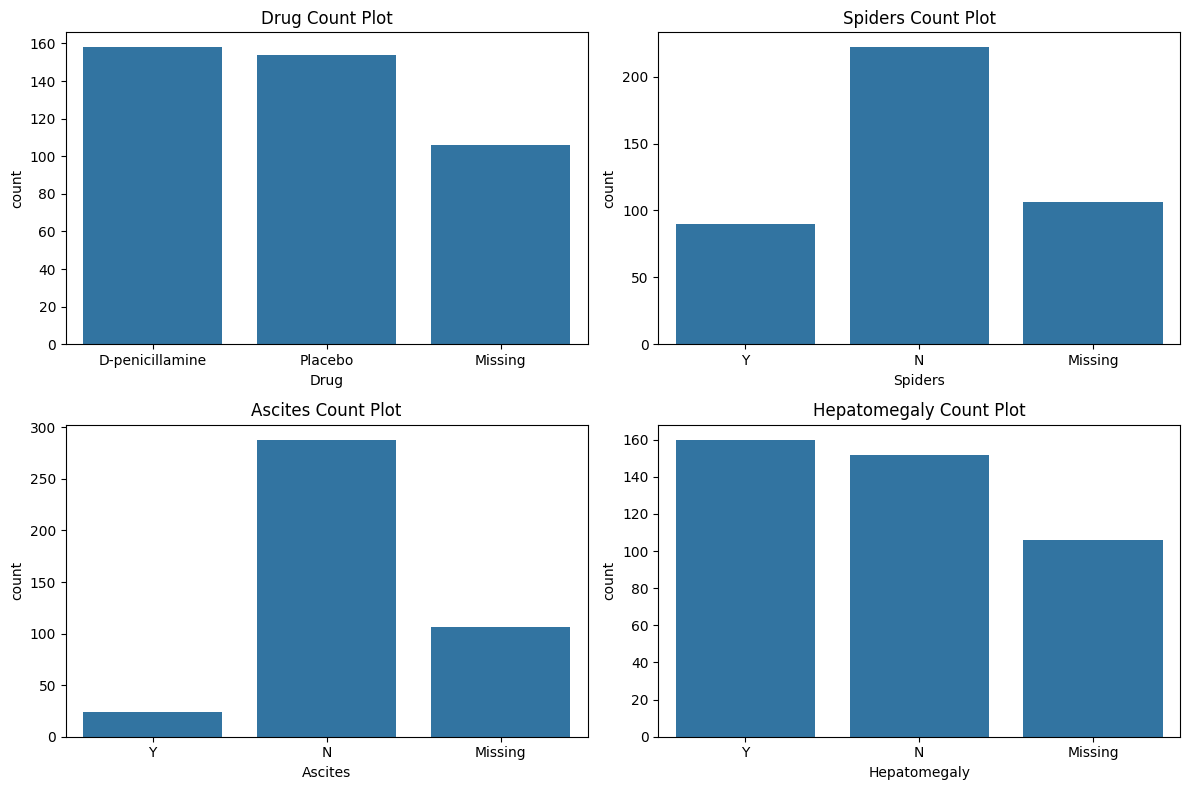

In [273]:
cat_cols = ['Drug', 'Spiders', 'Ascites', 'Hepatomegaly']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    # Temporary copy for visualization only
    temp = df[col].fillna("Missing")

    sns.countplot(x=temp, ax=axes[i])
    axes[i].set_title(f"{col} Count Plot")
    axes[i].set_xlabel(col)

plt.tight_layout()

> **Observations:**
>
> - The features `Drug`, `Spiders`, `Ascites`, and `Hepatomegaly` have missing values.
> - Each feature has about **106 missing values**, so dropping these rows would remove a large amount of data.
> - We will **not** fill the missing values with the mode because it would increase the most common category and may introduce bias.
> - Instead, we will replace the missing values with a new category called **"MISSING"**.
> - This keeps all the data and lets the model know that the value was originally missing, which may be useful for making predictions.

#### Inspecting Numeric Columns

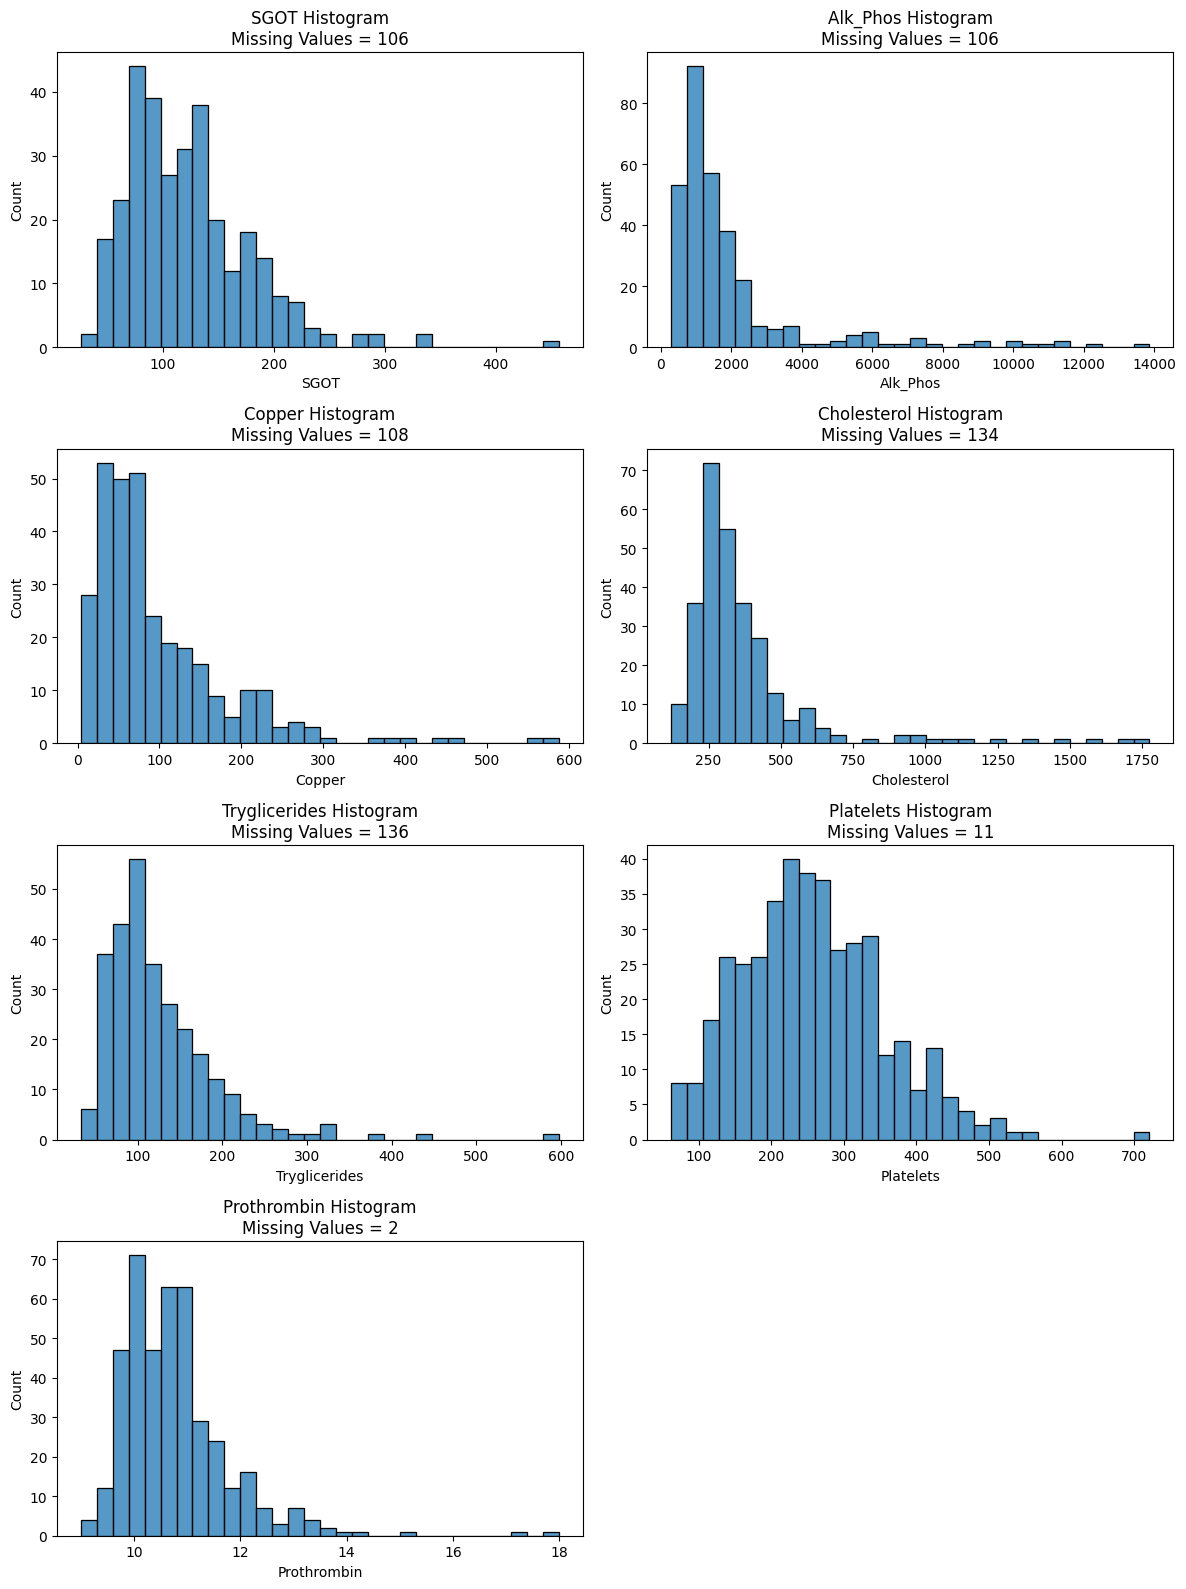

In [274]:
num_cols = [
    'SGOT',
    'Alk_Phos',
    'Copper',
    'Cholesterol',
    'Tryglicerides',
    'Platelets',
    'Prothrombin'
]

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    missing = df[col].isna().sum()

    sns.histplot(data=df, x=col, bins=30, ax=axes[i])

    axes[i].set_title(f"{col} Histogram\nMissing Values = {missing}")

# Remove the extra empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()

> **Observations:**
>
> - The numerical features (`SGOT`, `Alk_Phos`, `Copper`, `Cholesterol`, `Tryglicerides`, `Platelets`, and `Prothrombin`) contain missing values.
> - Most of these features are **right-skewed** and contain some **outliers**.
> - Because the data is not normally distributed, the **median** is a better choice than the mean for filling the missing values.
> - The median is less affected by extreme values, so it keeps the data more representative.
> - Therefore, all missing values in these numerical features will be imputed using the **median**.

## Exploratory Data Analysis

### Correlation Heatmap


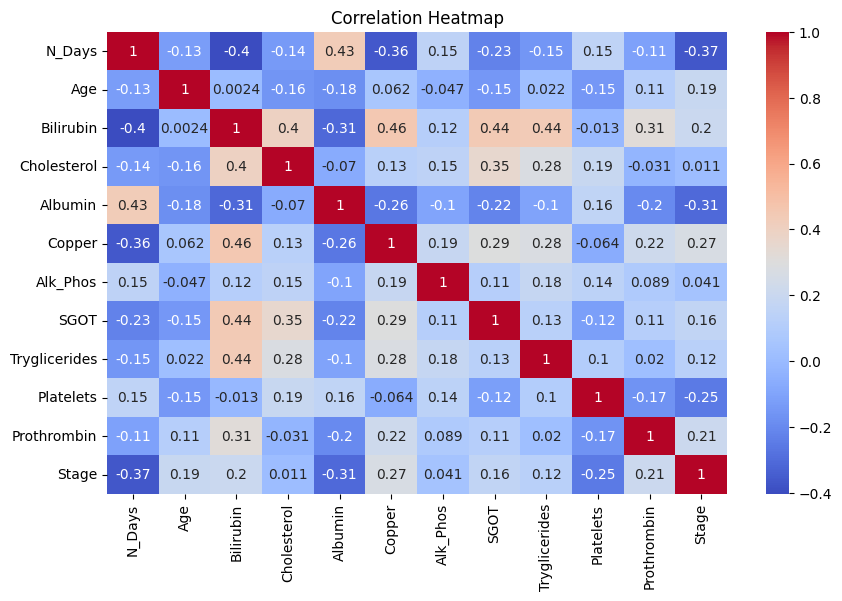

In [275]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
ax = sns.heatmap(corr, annot=True, cmap='coolwarm')
ax.set_title("Correlation Heatmap");

> **Observation:**
> - The heatmap shows mostly weak to moderate correlations between the numerical features.
> -  although none of them are very strong, There is no serious multicollinearity because no pair of features has a correlation close to 0.8 or higher.
>- Therefore, the numerical columns do not need to be removed based on multicollinearity alone.

## Feature Inspection

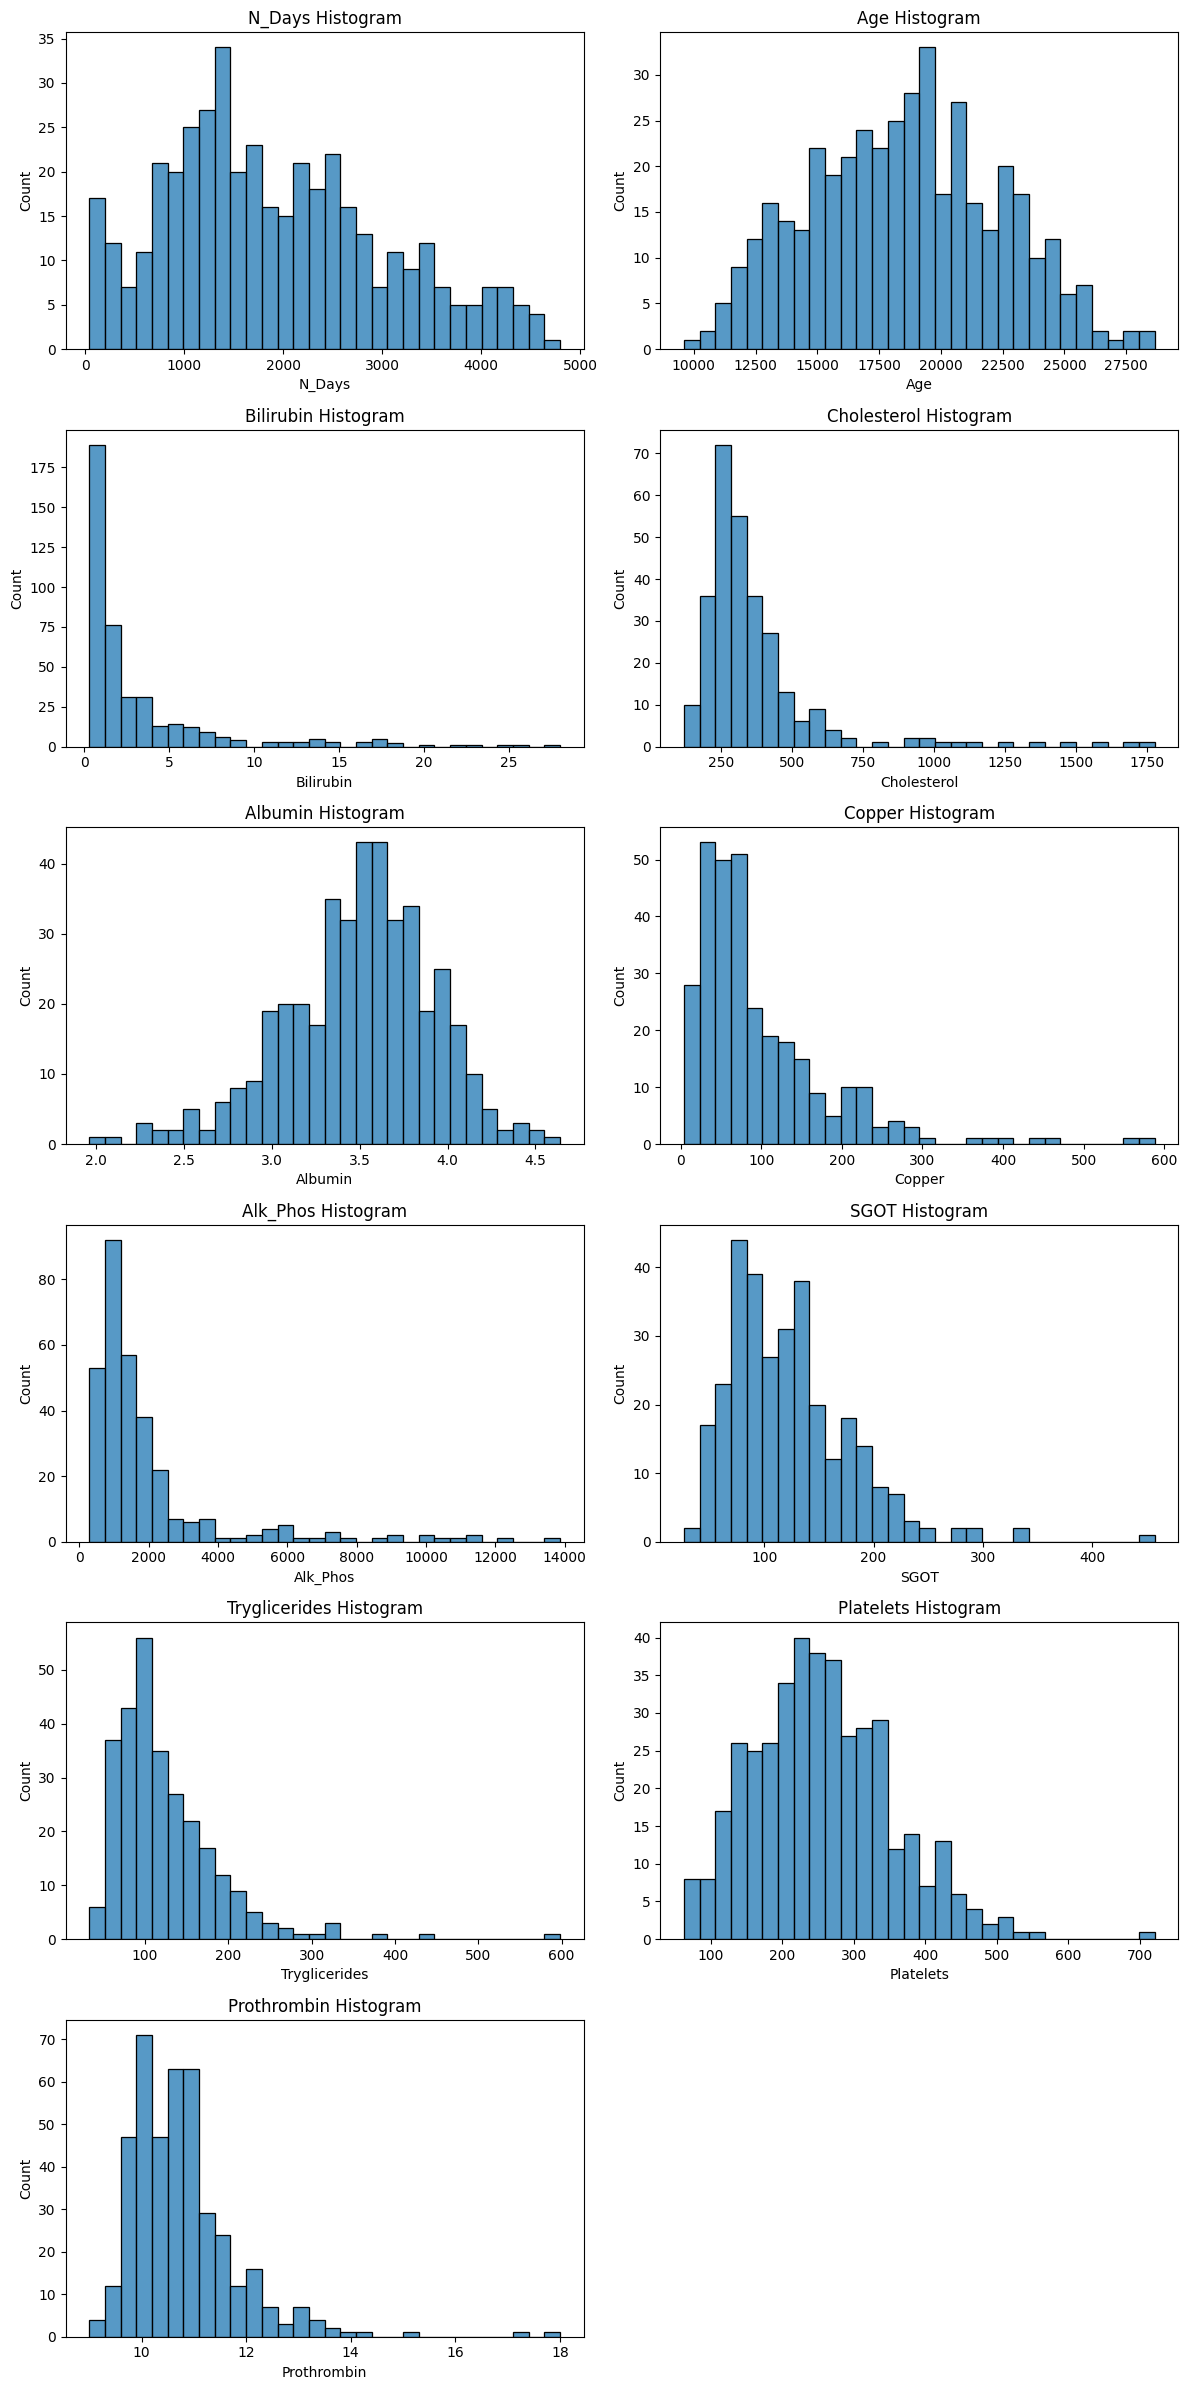

In [276]:
num_cols=df.select_dtypes('number').drop(columns=['Stage']).columns
fig, axes = plt.subplots(6, 2, figsize=(12, 24))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, bins=30, ax=axes[i])

    axes[i].set_title(f"{col} Histogram")

# Remove the extra empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()

> **Observations:**
>
> - `Age`, `Albumin`, and `N_Days` have distributions that are closer to normal.
> - `Bilirubin`, `Cholesterol`, `Copper`, `Alk_Phos`, `SGOT`, `Tryglicerides`, `Platelets`, and `Prothrombin` are mostly right-skewed.
> - Some numerical features contain very high values, which may be outliers.
> - These high values may represent real medical cases, so they should not be removed without investigation.
> - Missing numerical values will be filled using the **median**.
> - The median is a good choice because it is less affected by extreme values and skewed distributions.
> - The imputer will be fitted only on the training data using a pipeline to avoid data leakage.

### Inspect Outliers

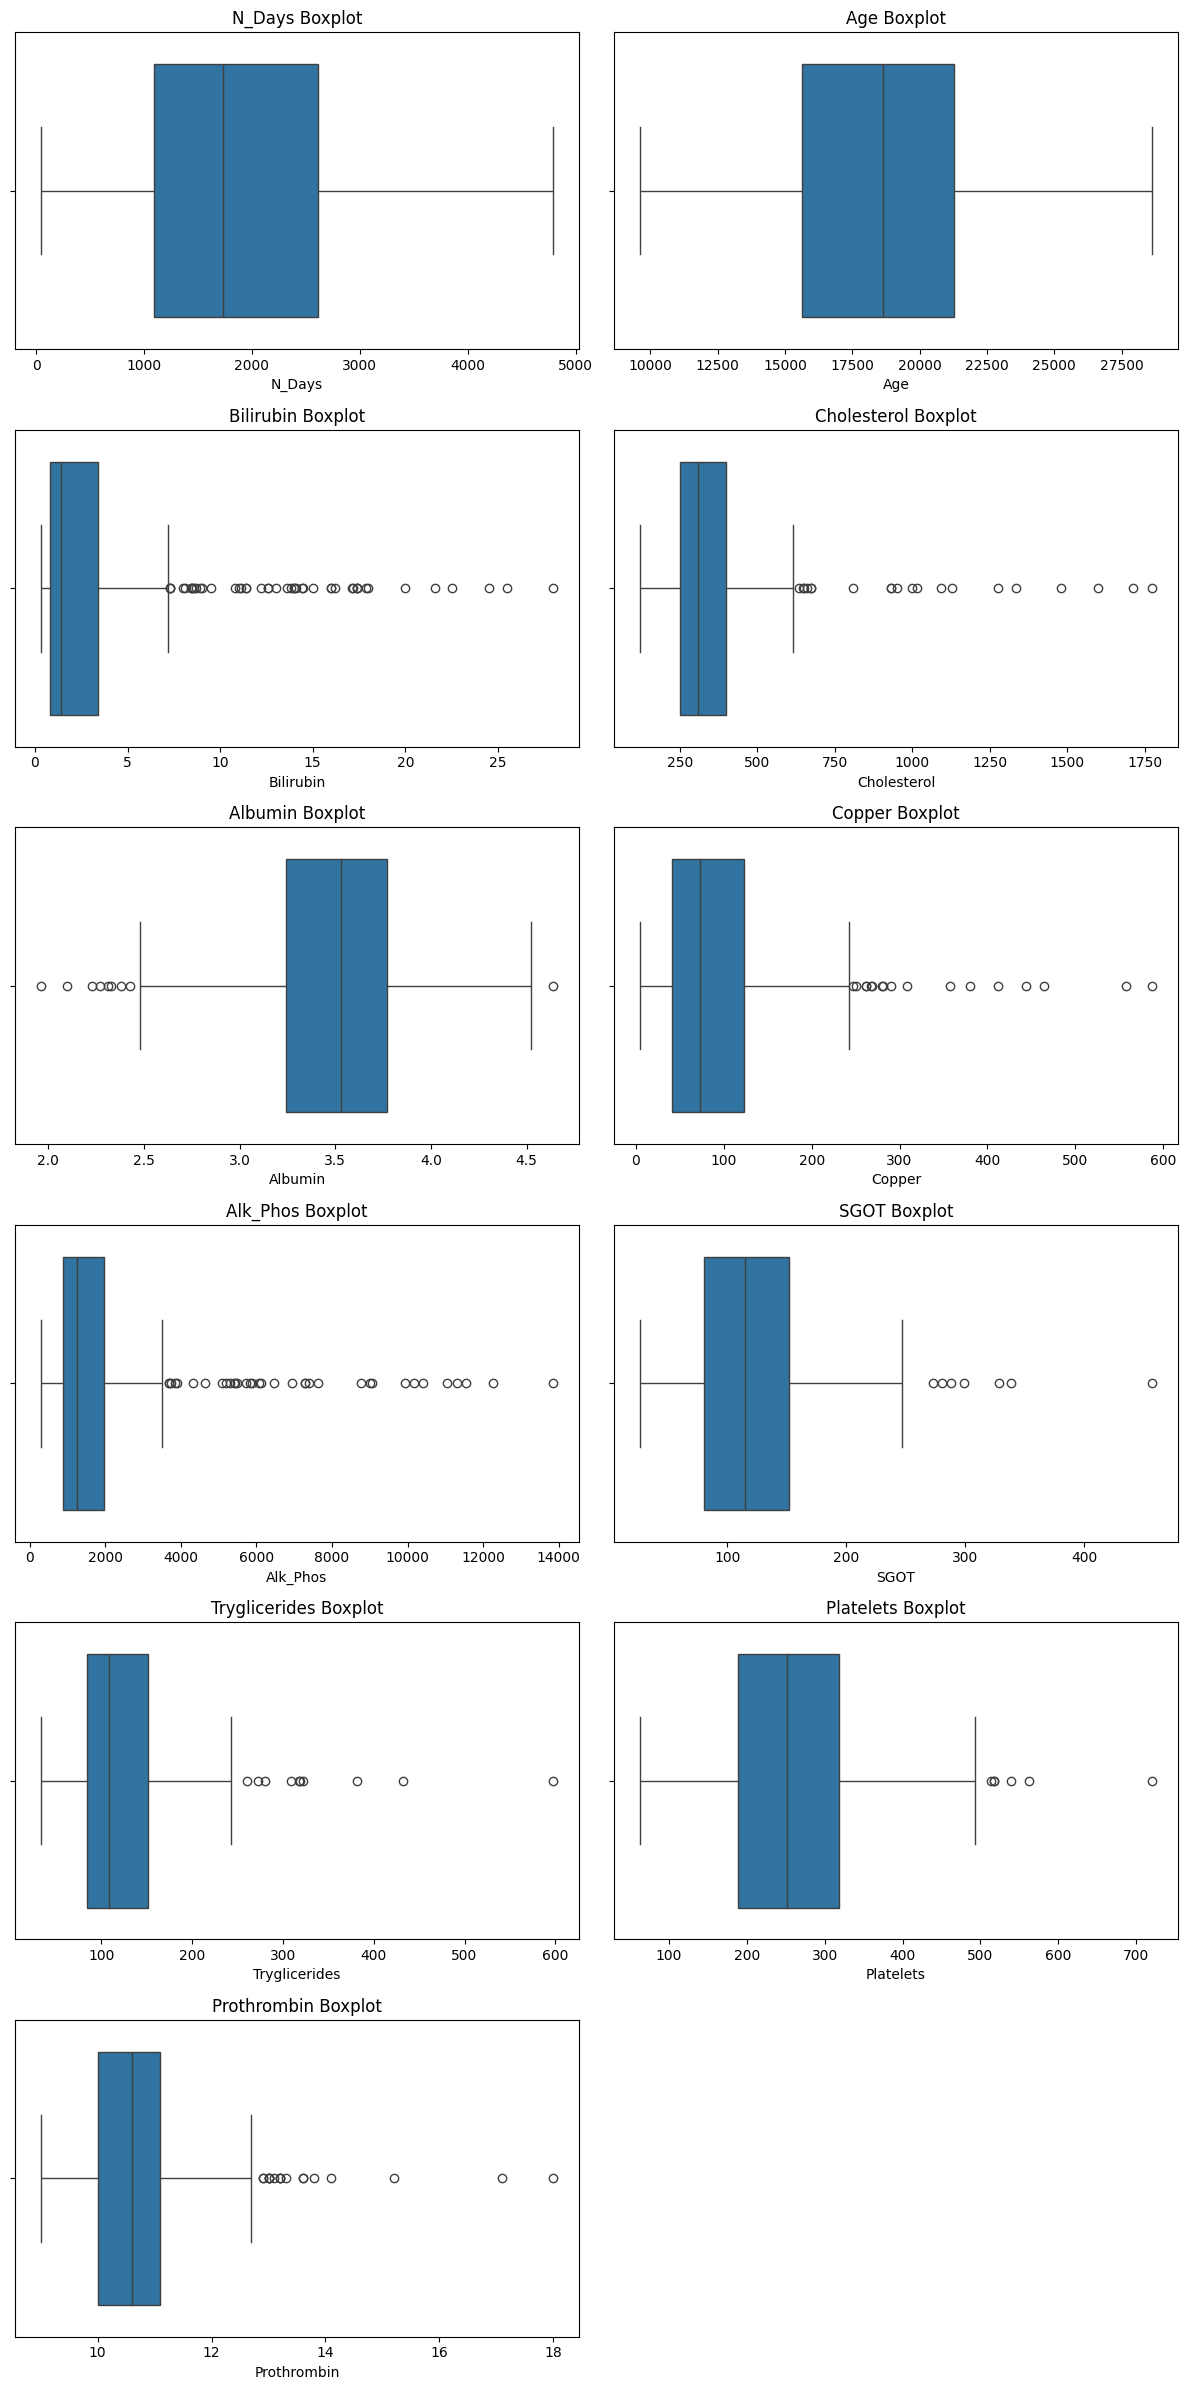

In [277]:
num_cols=df.select_dtypes('number').drop(columns=['Stage']).columns
# boxplot
fig, axes = plt.subplots(6, 2, figsize=(12, 24))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"{col} Boxplot")

# Remove unused plots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

> **Observations:**
>
> - Boxplots were used to check for possible outliers in the numerical features.
> - `N_Days` and `Age` do not show noticeable outliers.
> - `Albumin` contains a few low outliers.
> - `Bilirubin`, `Cholesterol`, `Copper`, `Alk_Phos`, `SGOT`, `Tryglicerides`, `Platelets`, and `Prothrombin` contain several high outliers.
> - Since this is a medical dataset, these extreme values may represent patients with severe liver disease rather than data entry errors.
> - Therefore, the outliers will be **kept** and not removed.

## Preprocessing

> **Feature Removal:**  
> The `N_Days` feature was removed before training the model because it shows the number of days until the patient's final outcome was recorded.
>
> - Since the target is `Status`, this feature is very closely related to the target.
> - If `N_Days` is included, the model may use it instead of learning from the patient's medical features.
> - Removing `N_Days` helps the model make predictions using only the patient's clinical information, making the model more realistic and better for new patients.

In [278]:
# split data
y = df['Status']
X = df.drop(columns=['Status', 'N_Days'])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

# ordinal category orders
edema_order = ['N', 'S', 'Y']
stage_order = [1.0,2.0,3.0,4.0]

ord_cols = ['Edema','Stage']

# ordinal pipeline
ord_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OrdinalEncoder(categories=[edema_order, stage_order]),
    StandardScaler()
)

ord_tuple = ('Ordinal', ord_pipe, ord_cols)

# Nominal categorical columns
ohe_cols = (
    X_train
    .select_dtypes(include='object')
    .columns
    .difference(['Edema'])
)

ohe_pipe = make_pipeline(
  SimpleImputer(strategy='constant', fill_value='MISSING'),
  OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'),
)

# drop first to avoid multicollinearity
ohe_tuple = ('Categorical', ohe_pipe , ohe_cols)

# Numeric columns, excluding Stage
num_cols = (
    X_train
    .select_dtypes(include='number')
    .columns
    .difference(['Stage'])
)

num_pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler()) # fill with median
num_tuple = ('Numeric', num_pipe, num_cols)

preprocessor = ColumnTransformer(
  [num_tuple, ord_tuple, ohe_tuple],
  verbose_feature_names_out=False
)

In [279]:
# model evaluation function
def classification_metrics(y_true,y_pred,label='',output_dict=False,figsize=(8, 4),normalize='true',cmap='Blues',colorbar=False):
    # Get the classification report
    report = classification_report(y_true, y_pred)

    # Print header and report
    header = "--" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    # CONFUSION MATRICES SUBPLOTS
    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    # Create a confusion matrix of raw counts
    ConfusionMatrixDisplay.from_predictions(y_true,y_pred,normalize=None,cmap='gist_gray',colorbar=colorbar,ax=axes[0])
    axes[0].set_title("Raw Counts")

    # Create a normalized confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_true,y_pred,normalize=normalize,cmap=cmap,colorbar=colorbar,ax=axes[1] )
    axes[1].set_title("Normalized Confusion Matrix")

    # Adjust layout and show figure
    fig.tight_layout()
    plt.show()

    # Return dictionary version of classification_report
    if output_dict == True:
        report_dict = classification_report(
            y_true,
            y_pred,
            output_dict=True
        )
        return report_dict
def evaluate_classification(model,X_train,y_train,X_test,y_test,figsize=(6, 4),normalize='true',output_dict=False,cmap_train="Blues",cmap_test="Reds",colorbar=False):
    # Get predictions for training data
    y_train_pred = model.predict(X_train)

    # Call the helper function to obtain classification metrics for training data
    results_train = classification_metrics(y_train,y_train_pred,output_dict=True,figsize=figsize,colorbar=colorbar,cmap=cmap_train,label='Training Data')

    print()

    # Get predictions for test data
    y_test_pred = model.predict(X_test)

    # Call the helper function to obtain classification metrics for test data
    results_test = classification_metrics( y_test, y_test_pred,output_dict=True,figsize=figsize,colorbar=colorbar,cmap=cmap_test,label='Test Data')

    if output_dict == True:
        # Store results in a dictionary if output_dict is True
        results_dict = {
            'train': results_train,
            'test': results_test
        }
        return results_dict

In [280]:
# check class balance
y_train.value_counts(normalize=True)

,proportion
Status,
C,0.555911
D,0.383387
CL,0.060703


> **Observation:**  
> The target variable `Status` is imbalanced.
> Most patients belong to class `C` (55.6%), followed by class `D` (38.3%).
>
>- Class `CL` represents only 6.1% of the training data, making it the minority class.
>-  This class imbalance may make it more difficult for the model to correctly predict the `CL` class, so evaluation should focus on metrics such as the **Macro F1-score** instead of accuracy alone.

## Model: Random Forest Classifier

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           C       1.00      1.00      1.00       174
          CL       1.00      1.00      1.00        19
           D       1.00      1.00      1.00       120

    accuracy                           1.00       313
   macro avg       1.00      1.00      1.00       313
weighted avg       1.00      1.00      1.00       313



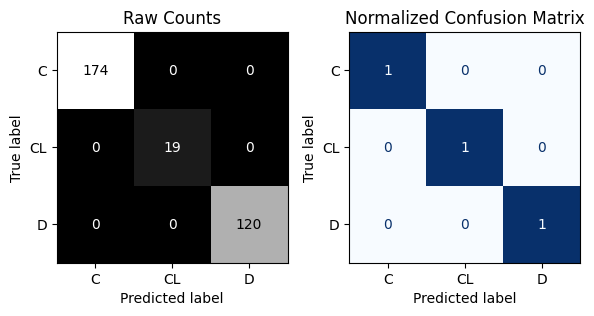


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           C       0.72      0.88      0.79        58
          CL       0.00      0.00      0.00         6
           D       0.76      0.63      0.69        41

    accuracy                           0.73       105
   macro avg       0.49      0.50      0.49       105
weighted avg       0.70      0.73      0.71       105



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


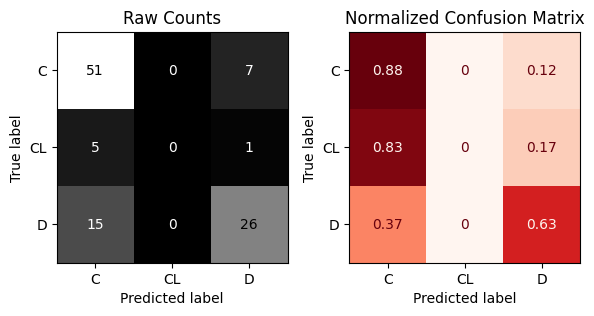

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [281]:
# default model
rf = RandomForestClassifier(random_state=42)
rf_pipe = make_pipeline(preprocessor, rf)

rf_pipe.fit(X_train, y_train)

evaluate_classification(rf_pipe,X_train, y_train, X_test, y_test)

> **Observations:**
>
> - The model achieved a **Macro F1-score of 1.00** on the training data but only **0.49** on the test data. This suggests that the model is **overfitting**.
>
> - The model performed well for the `C` class (F1-score = **0.79**) and showed moderate performance for the `D` class (F1-score = **0.69**).
>
> - The model did not correctly predict any patients in the `CL` class, giving an F1-score of **0.00**.
>
> - This is mostly because the `CL` class has very few samples and also depends on factors such as liver transplant decisions, which are not included in the dataset.
>
> - Overall, the low **Macro F1-score** on the test data shows that the model does not predict all three classes equally well.

### Feature Importance

In [282]:
# Function to create a color dictionary
def get_color_dict(
    importances,
    color_rest='#006ba4',
    color_top='green',
    top_n=5
):
    # Get the names of the top features
    highlight_feats = (
        importances
        .sort_values(ascending=True)
        .tail(top_n)
        .index
    )

    # Assign green to top features and blue to the remaining features
    colors_dict = {
        col: color_top if col in highlight_feats else color_rest
        for col in importances.index
    }

    return colors_dict

# Function to plot feature importance
def plot_importance_color(
    importances,
    top_n=None,
    figsize=(8, 6),
    color_dict=None
):
    # Sort the importance values
    if top_n is None:
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"

    # Plot using the provided colors
    if color_dict is not None:
        colors = plot_vals.index.map(color_dict)

        ax = plot_vals.plot(
            kind='barh',
            figsize=figsize,
            color=colors
        )

    else:
        ax = plot_vals.plot(
            kind='barh',
            figsize=figsize
        )

    # Labels and title
    ax.set(
        xlabel='Importance',
        ylabel='Feature Names',
        title=title
    )

    return ax

In [283]:
# Calculate permutation importance using unseen test data
r = permutation_importance(
    rf_pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro',
    n_jobs=-1
)

# Check the returned results
r.keys()

dict_keys(['importances_mean', 'importances_std', 'importances'])

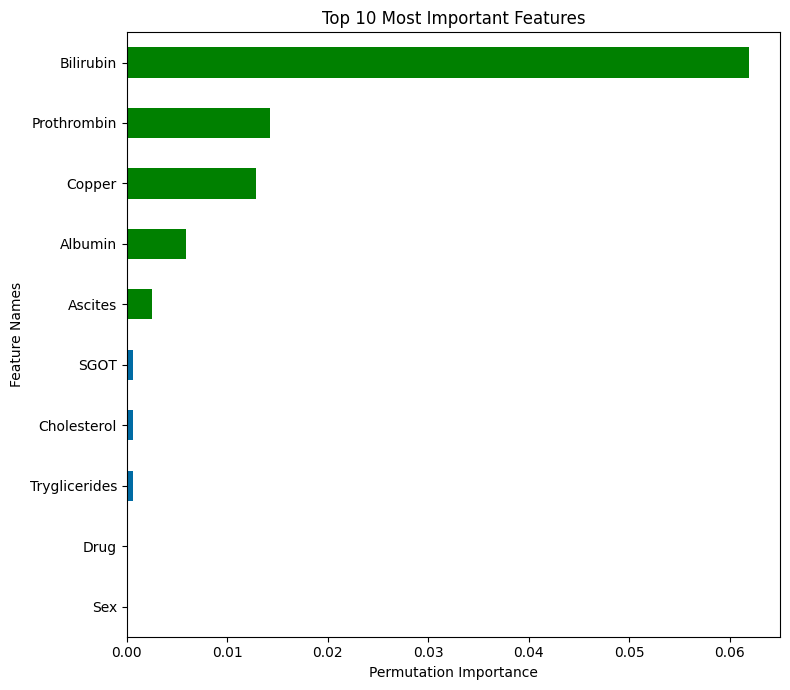

In [284]:
# Convert mean permutation importances into a Series
permutation_importances = pd.Series(
    r['importances_mean'],
    index=X_test.columns,
    name='Permutation Importance'
)

# Sort from highest to lowest
permutation_importances = permutation_importances.sort_values(
    ascending=False
)

colors_top5 = get_color_dict(
    permutation_importances,
    top_n=5
)

ax = plot_importance_color(
    permutation_importances,
    color_dict=colors_top5,
    top_n=10,
    figsize=(8, 7)
)

ax.set_xlabel("Permutation Importance")

plt.tight_layout()

> **Observation:**  
> Permutation importance shows that `Bilirubin` is the most important feature for predicting `Status`, with a much higher importance score than the other features.
>- `Prothrombin` and `Copper` are the next most important features, while `Albumin` and `Ascites` have a smaller contribution.
>- The remaining features have importance values close to zero, suggesting that they have little effect on the model's predictions.
>-  Overall, the model relies mainly on a few key clinical measurements, especially `Bilirubin`, to predict the patient's `Status`.

### Explanatory Data Analysis

In [285]:
def plot_feature_by_status(
    df,
    feature,
    target='Status',
    figsize=(8, 5),
    order=('C', 'CL', 'D')
):
    # Create a temporary copy for visualization
    temp_df = df[[feature, target]].copy()

    # Remove rows missing the feature or target
    temp_df = temp_df.dropna(subset=[feature, target])

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Show individual patient observations
    sns.stripplot(
        data=temp_df,
        x=target,
        y=feature,
        hue=target,
        order=order,
        hue_order=order,
        legend=False,
        edgecolor='white',
        linewidth=0.5,
        size=4,
        alpha=0.7,
        jitter=0.25,
        zorder=0,
        ax=ax
    )

    # Show the average feature value for each status
    sns.barplot(
        data=temp_df,
        x=target,
        y=feature,
        order=order,
        errorbar=None,
        alpha=0.6,
        linewidth=1,
        edgecolor='black',
        ax=ax
    )

    # Labels
    ax.set_title(
        f"Average {feature} by Patient Status",
        fontsize=14,
        fontweight='bold'
    )

    ax.set_xlabel("Patient Status", fontsize=11)
    ax.set_ylabel(feature, fontsize=11)

    fig.tight_layout()

    return fig, ax

#### Bilirubin vs Status

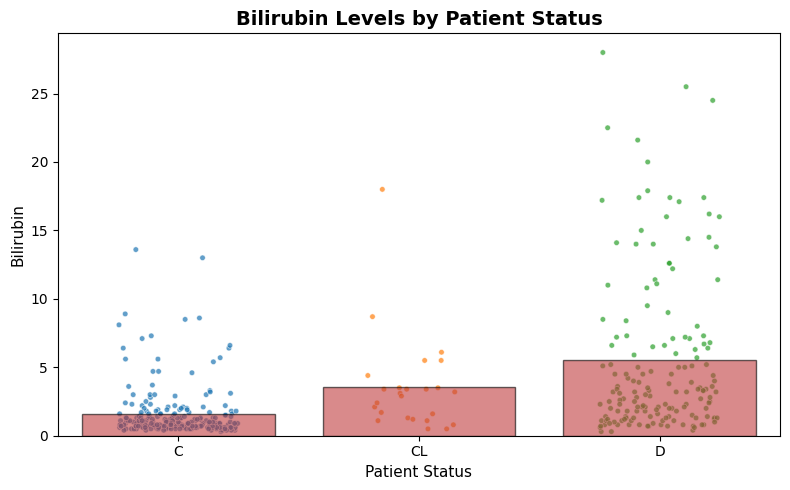

In [286]:
status_order = ['C', 'CL', 'D']

fig, ax = plot_feature_by_status(
    df,
    feature='Bilirubin',
    order=status_order,
    figsize=(8, 5)
)

ax.set_title(
    "Bilirubin Levels by Patient Status",
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel("Patient Status")
ax.set_ylabel("Bilirubin");

> **Observation:**  
> Patients with a `Status` of `D` have the highest `Bilirubin` levels on average.
>- Patients with a `Status` of `CL` also have higher `Bilirubin` levels than patients with a `Status` of `C`.
>
> Although some values overlap, higher `Bilirubin` levels are more common in patients with a `Status` of `D` (death).

#### Stage vs. Status

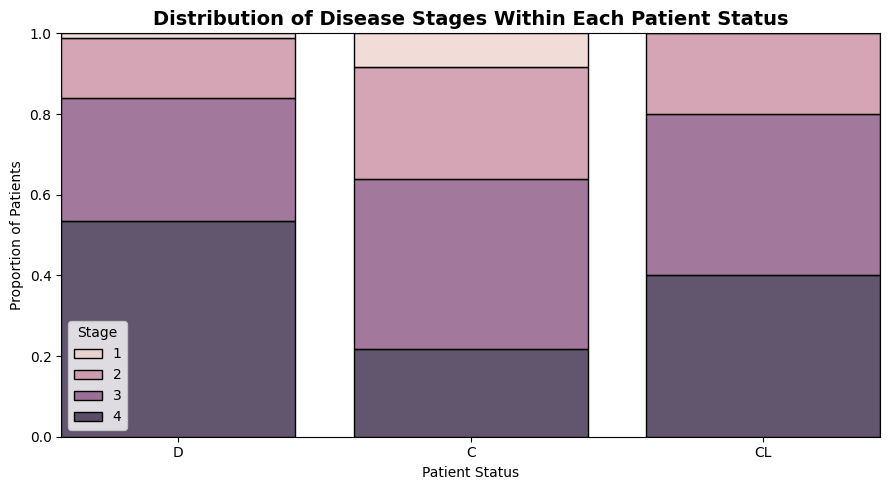

In [287]:
# Remove missing values only for visualization
temp_df = df.dropna(subset=['Stage', 'Status']).copy()

# Convert Stage to integer labels
temp_df['Stage'] = temp_df['Stage'].astype(int)

plt.figure(figsize=(9, 5))

sns.histplot(
    data=temp_df,
    x='Status',
    hue='Stage',
    hue_order=[1, 2, 3, 4],
    multiple='fill',
    shrink=0.8
)

plt.title(
    "Distribution of Disease Stages Within Each Patient Status",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Patient Status")
plt.ylabel("Proportion of Patients")

plt.tight_layout()
plt.show()

> **Observation:**
> - patients with a `Status` of `D` have the highest proportion of `Stage` 4 disease, meaning that more severe disease stages are more common among patients who died.
> - Patients with a `Status` of `C` are more evenly distributed across `Stage` 2, `Stage` 3, and `Stage` 4, with fewer patients in `Stage` 1.
>-  Patients with a `Status` of `CL` also have a relatively high proportion of `Stage` 3 and `Stage` 4 cases.
>
>- Overall, the distribution suggests that advanced disease stages are more common in patients with worse outcomes, although all `Status` groups contain patients from multiple disease stages.

## Feature Engineering

### Overview

In this section, two feature engineering approaches are applied:

1. **PCA**: 3 principal components computed from the preprocessed features.
2. **KMeans clustering**: cluster labels used as a new categorical feature.
3. **Feature selection (embedded method)**: `SelectFromModel` with a Random Forest.

### 1) PCA - 3 Principal Components

In [288]:
scale_pipe = make_pipeline(preprocessor, StandardScaler())

pca_pipe = make_pipeline(
    scale_pipe,
    PCA(n_components=3, random_state=42)
)

# fit & transform
pca_pipe.fit(X_train, y_train)
pc_train =pca_pipe.transform(X_train)
pc_test = pca_pipe.transform(X_test)

# concatinate
X_train_pca= pd.concat([X_train.reset_index(drop=True), pc_train.reset_index(drop=True)],axis=1)
X_test_pca= pd.concat([X_test.reset_index(drop=True), pc_test.reset_index(drop=True)], axis=1)


pca = pca_pipe.named_steps['pca']

# Print explained variance
print(
    "Explained variance ratio per component:",
    pca.explained_variance_ratio_.round(3)
)

print(
    "Total variance explained by the 3 PCs:",
    round(pca.explained_variance_ratio_.sum(), 3)
)

# view
X_train_pca.head()

Explained variance ratio per component: [0.184 0.148 0.09 ]
Total variance explained by the 3 PCs: 0.421


,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,pca0,pca1,pca2
0,D-penicillamine,23235,F,N,Y,N,N,0.9,420.0,3.87,30.0,1009.0,57.35,232.0,NaN,9.7,3.0,-0.704325,-0.652602,-0.062217
1,D-penicillamine,18393,F,N,N,N,N,0.4,127.0,3.50,14.0,1062.0,49.60,84.0,334.0,10.3,2.0,-2.780667,0.389307,-1.135445
2,D-penicillamine,14872,F,N,N,N,N,2.1,392.0,3.43,52.0,1395.0,184.45,194.0,328.0,10.2,3.0,-1.355976,-0.995376,0.722356
3,Placebo,19295,M,N,N,N,N,3.2,259.0,4.30,208.0,1040.0,110.05,78.0,268.0,11.7,3.0,-1.442391,-1.001734,-1.559630
4,Placebo,22173,F,Y,N,N,N,1.3,302.0,2.75,58.0,1523.0,43.40,112.0,329.0,13.2,4.0,1.026662,0.670748,-3.528795


> **Observation:**
> - The first 3 principal components together explain about **42%** of the total variance in the preprocessed features.
> - No single component dominates, which is expected since the original correlation heatmap didnt dhow strong correlations between features (there isn't one strong underlying pattern for PCA to compress into a couple of components).

#### Random Forest - With PCA

In [289]:
pca_cols=['pca0', 'pca1', 'pca2']
pca_tuple=('PCA_Features','passthrough',pca_cols) # 'passthrough' means dont transform these features
preprocessor_pca= ColumnTransformer(
    [num_tuple, ord_tuple, ohe_tuple, pca_tuple],
    verbose_feature_names_out=False
)

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           C       1.00      1.00      1.00       174
          CL       1.00      1.00      1.00        19
           D       1.00      1.00      1.00       120

    accuracy                           1.00       313
   macro avg       1.00      1.00      1.00       313
weighted avg       1.00      1.00      1.00       313



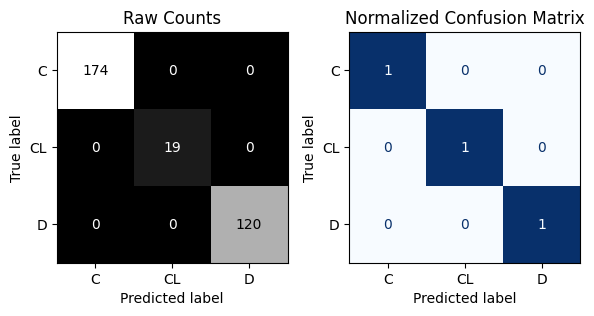


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           C       0.71      0.88      0.78        58
          CL       0.00      0.00      0.00         6
           D       0.76      0.61      0.68        41

    accuracy                           0.72       105
   macro avg       0.49      0.50      0.49       105
weighted avg       0.69      0.72      0.70       105



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


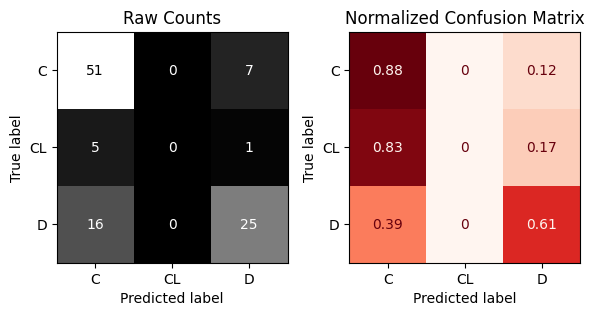

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [290]:
rf_pca= RandomForestClassifier(random_state=42)
rf_pca_pipe= make_pipeline(preprocessor_pca, rf_pca)

rf_pca_pipe.fit(X_train_pca, y_train)

evaluate_classification(rf_pca_pipe, X_train_pca, y_train, X_test_pca, y_test)

> **PCA Random Forest Observations:**
>
> - Adding the 3 PCA components did **not** improve the model.
> - The test Macro F1-score stayed almost the same (**0.49** before vs **0.49** after).
> - The `C` and `D` classes performed about the same as before.
> - The `CL` class is still at **0.00** F1-score, just like before. This is because `CL` only has 19 samples in training, so PCA does not fix that problem.
> - The model is still **overfitting**, since training score is 1.00 but test score is much lower.
> - This means the PCA components did not add any new useful information for the Random Forest. The model was probably already able to find the important patterns from the original features on its own.
> - PCA usually helps more with models like Logistic Regression (Linear Models), not tree models like Random Forest, so this result makes sense.

### 2) KMeans Clustering

In [291]:
X_train_pre = scale_pipe.fit_transform(X_train)
X_test_pre = scale_pipe.transform(X_test)

Silhouette scores by k: [np.float64(0.192), np.float64(0.184), np.float64(0.211), np.float64(0.217), np.float64(0.216)]


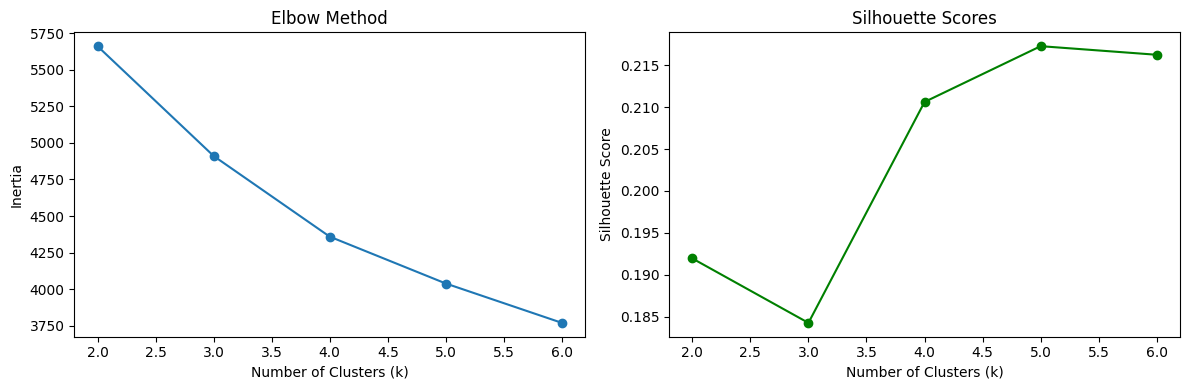

In [292]:
# Try a range of cluster counts and compare inertia (elbow) and silhouette score
k_range = range(2, 7);
inertias = [];
sil_scores = [];

for k in k_range:
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10);
    labels = km_test.fit_predict(X_train_pre);
    inertias.append(km_test.inertia_);
    sil_scores.append(silhouette_score(X_train_pre, labels));

fig, axes = plt.subplots(1, 2, figsize=(12, 4));

axes[0].plot(list(k_range), inertias, marker='o');
axes[0].set_title("Elbow Method");
axes[0].set_xlabel("Number of Clusters (k)");
axes[0].set_ylabel("Inertia");

axes[1].plot(list(k_range), sil_scores, marker='o', color='green');
axes[1].set_title("Silhouette Scores");
axes[1].set_xlabel("Number of Clusters (k)");
axes[1].set_ylabel("Silhouette Score");

plt.tight_layout();

print("Silhouette scores by k:", [round(s, 3) for s in sil_scores]);

> **Observation:**
> - Silhouette scores peak at **k = 5**, so 5 clusters are used going forward.

In [293]:
best_k = 5

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

final_kmeans.fit(X_train_pre)

# predict cluster labels for train and test separately
cluster_labels_train = final_kmeans.predict(X_train_pre)
cluster_labels_test = final_kmeans.predict(X_test_pre)

# turn labels into DataFrames so pd.concat works
cluster_train_df = pd.DataFrame(cluster_labels_train, columns=['Cluster'])
cluster_test_df = pd.DataFrame(cluster_labels_test, columns=['Cluster'])

# reset index on BOTH sides so concat aligns row-by-row, not by old index labels
X_train_cluster = pd.concat(
    [X_train.reset_index(drop=True), cluster_train_df.reset_index(drop=True)],
    axis=1
)
X_test_cluster = pd.concat(
    [X_test.reset_index(drop=True), cluster_test_df.reset_index(drop=True)],
    axis=1
)

X_train_cluster.head()

,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Cluster
0,D-penicillamine,23235,F,N,Y,N,N,0.9,420.0,3.87,30.0,1009.0,57.35,232.0,NaN,9.7,3.0,2
1,D-penicillamine,18393,F,N,N,N,N,0.4,127.0,3.50,14.0,1062.0,49.60,84.0,334.0,10.3,2.0,4
2,D-penicillamine,14872,F,N,N,N,N,2.1,392.0,3.43,52.0,1395.0,184.45,194.0,328.0,10.2,3.0,4
3,Placebo,19295,M,N,N,N,N,3.2,259.0,4.30,208.0,1040.0,110.05,78.0,268.0,11.7,3.0,4
4,Placebo,22173,F,Y,N,N,N,1.3,302.0,2.75,58.0,1523.0,43.40,112.0,329.0,13.2,4.0,1


#### Clusters

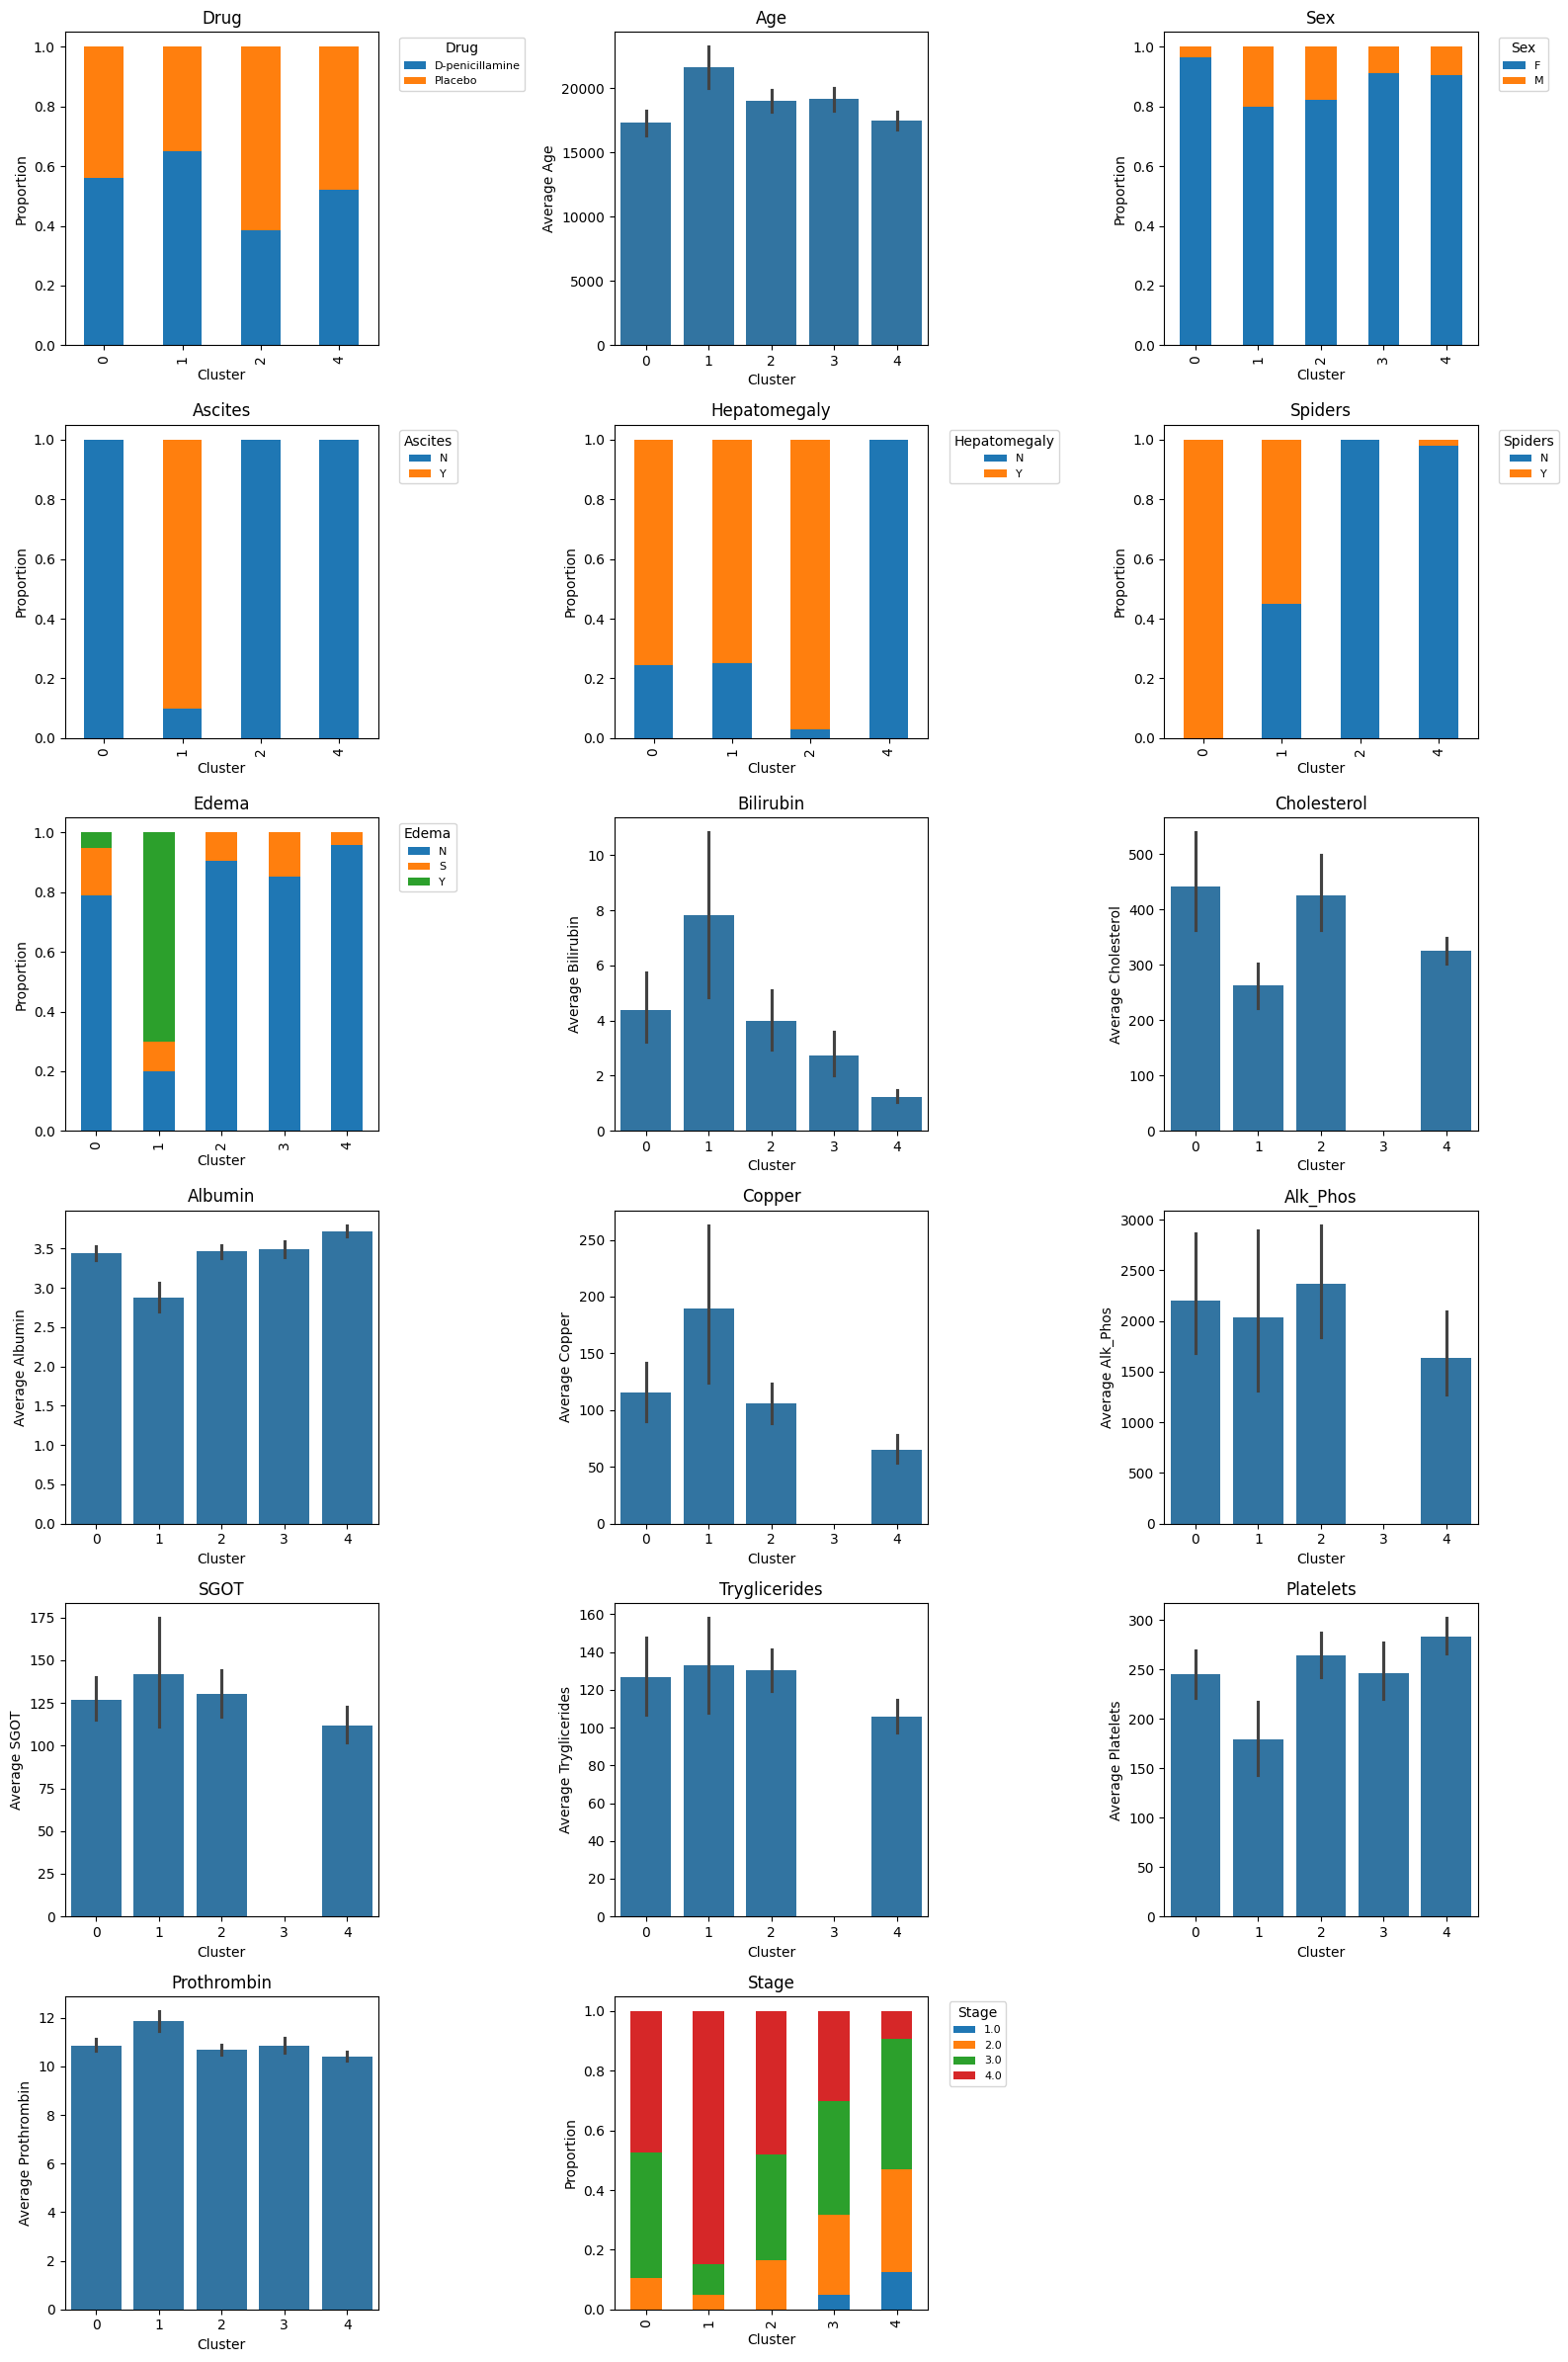

In [310]:
edema_order = ['N', 'S', 'Y']
stage_order = [1.0, 2.0, 3.0, 4.0]
ord_cols = ['Edema', 'Stage']

feature_cols = [col for col in X_train_cluster.columns if col != 'Cluster']

n_cols = 3
n_rows = -(-len(feature_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    if col == 'Edema':
        # ordinal -> stacked proportions, kept in clinical order N < S < Y
        ct = pd.crosstab(X_train_cluster['Cluster'], X_train_cluster[col], normalize='index')
        ct = ct.reindex(columns=edema_order, fill_value=0)
        ct.plot(kind='bar', stacked=True, ax=axes[i], legend=True)
        axes[i].legend(title=col, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[i].set_ylabel("Proportion")

    elif col == 'Stage':
        # ordinal -> stacked proportions, kept in order 1 < 2 < 3 < 4
        ct = pd.crosstab(X_train_cluster['Cluster'], X_train_cluster[col], normalize='index')
        ct = ct.reindex(columns=stage_order, fill_value=0)
        ct.plot(kind='bar', stacked=True, ax=axes[i], legend=True)
        axes[i].legend(title=col, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[i].set_ylabel("Proportion")

    elif X_train_cluster[col].dtype == 'object':
        # nominal categorical -> stacked proportions, no specific order needed
        ct = pd.crosstab(X_train_cluster['Cluster'], X_train_cluster[col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], legend=True)
        axes[i].legend(title=col, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[i].set_ylabel("Proportion")

    else:
        # numeric -> average per cluster
        sns.barplot(data=X_train_cluster, x='Cluster', y=col, ax=axes[i])
        axes[i].set_ylabel(f"Average {col}")

    axes[i].set_title(col)
    axes[i].set_xlabel("Cluster")

for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

> **Cluster Descriptions:**
>
> - **Cluster 1 - Advanced Disease**
>
> - This group has the highest `Bilirubin`, highest `Copper`, highest `SGOT`, and highest `Prothrombin`.
>
> - It has the lowest `Albumin` and lowest `Platelets`.
>
> - This is the only cluster with real `Ascites` cases.
>
> - Almost all patients here have `Edema`, and this is the only cluster with the severe type (`Edema` = Y).
>
> - Looking at `Stage`, most patients in this cluster are `Stage` 4, the most severe stage.
>
> - These patients also tend to be older.
>
> - This means these patients are the sickest group in the whole dataset.
>
> - **Cluster 4 - Healthiest Group**
>
> - This group has the lowest `Bilirubin` and lowest `Copper`.
>
> - It has the highest `Albumin` and highest `Platelets`.
>
> - Almost no patients here have `Ascites`, `Hepatomegaly`, or `Spiders`.
>
> - Looking at `Stage`, this cluster has the most patients in `Stage` 1 and `Stage` 2, which are the early or less severe stages.
>
> - This means these patients are the closest to a healthy liver profile.
>
> - **Cluster 2 - Enlarged Liver but Stable Labs**
>
> - Almost every patient in this cluster has `Hepatomegaly` (97%).
>
> - But their other lab values (`Bilirubin`, `Albumin`, `Platelets`) are only a little high, not extreme like Cluster 1.
>
> - This cluster also has the highest `Alk_Phos`.
>
> - Looking at `Stage`, this group is close to Cluster 0, with a mix of Stage 3 and Stage 4.
>
> - This means these patients have an enlarged liver, but their disease might be at an earlier point or a different type than Cluster 1.
>
> - **Cluster 0 - Middle Group**
>
> - This group is in between Cluster 2 and Cluster 4 for most features.
>
> - It has high `Cholesterol`.
>
> - Looking at `Stage`, this group has a mix of `Stage` 3 and `Stage` 4, similar to Cluster 2.
>
> - No single feature stands out a lot here.
>
> - This means these patients don't clearly belong to the "sick" group or the "healthy" group.
>
> - **Cluster 3 - Missing Data Group**
>
> - This cluster has no bars at all for Drug, `Ascites`, `Hepatomegaly`, `Spiders`, `Cholesterol`, `Copper`, `Alk_Phos`, `SGOT`, `Platelets`, and `Tryglicerides`.
>
> - These are the exact same columns that had missing values in the original data.
>
> - Even the `Stage` distribution here looks different, with more `Stage` 2 and `Stage` 3 and very little `Stage` 4.
>
> - This means KMeans probably grouped these patients together because they are missing the same lab values, not because they are actually similar patients.
>
> - So this cluster is more of a data problem than a real patient group.
>
> **Recommendations:**
>
> - Patients who look like **Cluster 1** should be checked more closely, since their lab values and `Stage` show signs of the most advanced liver disease.
>
> - **Cluster 3** should not be treated as a real patient group. Before using clusters for real decisions, the missing data problem should be fixed first.

#### Random Forest - With Clusters

In [294]:
cluster_cols = ['Cluster']
cluster_tuple = ('Cluster_feature', 'passthrough', cluster_cols)

preprocessor_cluster = ColumnTransformer(
    [num_tuple, ord_tuple, ohe_tuple, cluster_tuple],
    verbose_feature_names_out=False
)

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           C       1.00      1.00      1.00       174
          CL       1.00      1.00      1.00        19
           D       1.00      1.00      1.00       120

    accuracy                           1.00       313
   macro avg       1.00      1.00      1.00       313
weighted avg       1.00      1.00      1.00       313



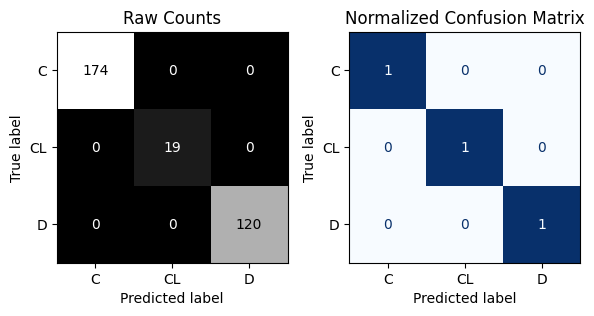


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           C       0.72      0.90      0.80        58
          CL       0.00      0.00      0.00         6
           D       0.79      0.63      0.70        41

    accuracy                           0.74       105
   macro avg       0.50      0.51      0.50       105
weighted avg       0.71      0.74      0.72       105



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


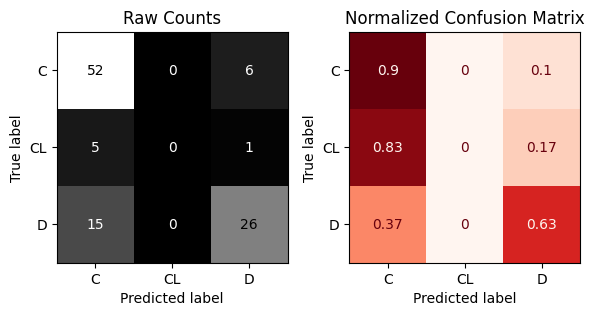

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [295]:
rf_cluster = RandomForestClassifier(random_state=42)
rf_cluster_pipe = make_pipeline(preprocessor_cluster, rf_cluster)

rf_cluster_pipe.fit(X_train_cluster, y_train)

evaluate_classification(rf_cluster_pipe, X_train_cluster, y_train, X_test_cluster, y_test)

> **Cluster Observations:**
>
> - Adding the `Cluster` feature gave a small improvement over the baseline.
> - The test Macro F1-score went from **0.49** (baseline) to **0.50** (with clusters).
> - The `C` class F1-score improved slightly (0.79 to 0.80), and the `D` class also improved slightly (0.69 to 0.70).
> - The `CL` class is still at **0.00** F1-score, same as before. Clustering does not fix the class imbalance problem.
> - The model is still **overfitting**, since training score is 1.00 but test score is much lower.
> - Compared to PCA, clustering helped a little more. This might be because the cluster groups similar patients together in a way that gives the Random Forest a slightly more useful signal than PCA.
> - The improvement is still small, so clustering alone does not solve the overfitting or class imbalance issues.

### Combine Engineered Features with the Original Features


In [296]:
X_train_combined = X_train.reset_index(drop=True).copy()
X_test_combined = X_test.reset_index(drop=True).copy()

# add the PCA columns
X_train_combined[['pca0', 'pca1', 'pca2']] = pc_train.reset_index(drop=True)
X_test_combined[['pca0', 'pca1', 'pca2']] = pc_test.reset_index(drop=True)

# add the Cluster column
X_train_combined['Cluster'] = cluster_labels_train
X_test_combined['Cluster'] = cluster_labels_test

X_train_combined.head()

,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,...,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,pca0,pca1,pca2,Cluster
0,D-penicillamine,23235,F,N,Y,N,N,0.9,420.0,3.87,...,1009.0,57.35,232.0,NaN,9.7,3.0,-0.704325,-0.652602,-0.062217,2
1,D-penicillamine,18393,F,N,N,N,N,0.4,127.0,3.50,...,1062.0,49.60,84.0,334.0,10.3,2.0,-2.780667,0.389307,-1.135445,4
2,D-penicillamine,14872,F,N,N,N,N,2.1,392.0,3.43,...,1395.0,184.45,194.0,328.0,10.2,3.0,-1.355976,-0.995376,0.722356,4
3,Placebo,19295,M,N,N,N,N,3.2,259.0,4.30,...,1040.0,110.05,78.0,268.0,11.7,3.0,-1.442391,-1.001734,-1.559630,4
4,Placebo,22173,F,Y,N,N,N,1.3,302.0,2.75,...,1523.0,43.40,112.0,329.0,13.2,4.0,1.026662,0.670748,-3.528795,1


### RandomForest With Engineered Features (PCA + Cluster)


In [297]:
engineered_cols = ['pca0', 'pca1', 'pca2', 'Cluster']
engineered_tuple = ('Engineered_features', 'passthrough', engineered_cols)

preprocessor_combined = ColumnTransformer(
    [num_tuple, ord_tuple, ohe_tuple, engineered_tuple],
    verbose_feature_names_out=False
)

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           C       1.00      1.00      1.00       174
          CL       1.00      1.00      1.00        19
           D       1.00      1.00      1.00       120

    accuracy                           1.00       313
   macro avg       1.00      1.00      1.00       313
weighted avg       1.00      1.00      1.00       313



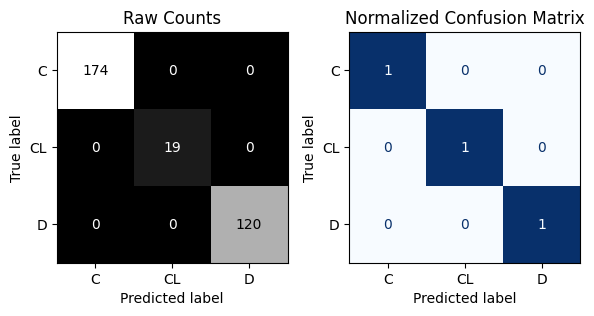


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           C       0.74      0.88      0.80        58
          CL       0.00      0.00      0.00         6
           D       0.75      0.66      0.70        41

    accuracy                           0.74       105
   macro avg       0.50      0.51      0.50       105
weighted avg       0.70      0.74      0.72       105



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


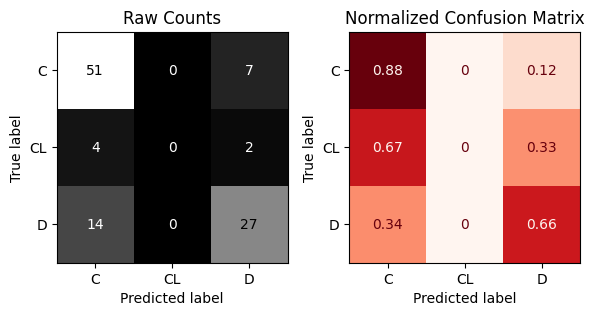

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [298]:
rf_combined = RandomForestClassifier(random_state=42)
rf_combined_pipe = make_pipeline(preprocessor_combined, rf_combined)

rf_combined_pipe.fit(X_train_combined, y_train)

evaluate_classification(rf_combined_pipe, X_train_combined, y_train, X_test_combined, y_test)

> **Combined Feature Engineering Observations (PCA + Cluster):**
>
> - Combining PCA and Cluster features together gave the same result as clustering alone.
> - The test Macro F1-score stayed at **0.50**, same as the cluster model.
> - `C` and `D` F1-scores also stayed the same (0.80 and 0.70).
> - `CL` is still stuck at **0.00** F1-score, showing that engineered features do not fix the class imbalance problem.
> - This means PCA is not adding anything extra once the `Cluster` feature is already included. Most of the small improvement is coming from clustering, not PCA.
> - The model is still **overfitting** (train score 1.00 vs test score much lower), so feature engineering alone did not solve that either.

### 3) Feature Selection: Embedded Method (`SelectFromModel`)

In [299]:
# using mean threashold
selector_mean = SelectFromModel(
    RandomForestClassifier(random_state=42),
    threshold='mean'
)

selector_pipe_mean = make_pipeline(preprocessor_combined, selector_mean)
selector_pipe_mean.fit(X_train_combined, y_train)

# which features got selected?
selected_mask = selector_pipe_mean.named_steps['selectfrommodel'].get_support()
all_feature_names = selector_pipe_mean.named_steps['columntransformer'].get_feature_names_out()
selected_features = all_feature_names[selected_mask]

print("Selected features:", list(selected_features))
print("Number selected:", len(selected_features), "out of", len(all_feature_names))

Selected features: ['Age', 'Albumin', 'Alk_Phos', 'Bilirubin', 'Cholesterol', 'Copper', 'Platelets', 'Prothrombin', 'SGOT', 'pca0', 'pca1', 'pca2']
Number selected: 12 out of 25


In [300]:
# using median threashold
selector_median = SelectFromModel(
    RandomForestClassifier(random_state=42),
    threshold='median'
)

selector_pipe_median = make_pipeline(preprocessor_combined, selector_median)
selector_pipe_median.fit(X_train_combined, y_train)

# which features got selected?
selected_mask = selector_pipe_median.named_steps['selectfrommodel'].get_support()
all_feature_names = selector_pipe_median.named_steps['columntransformer'].get_feature_names_out()
selected_features = all_feature_names[selected_mask]

print("Selected features:", list(selected_features))
print("Number selected:", len(selected_features), "out of", len(all_feature_names))

Selected features: ['Age', 'Albumin', 'Alk_Phos', 'Bilirubin', 'Cholesterol', 'Copper', 'Platelets', 'Prothrombin', 'SGOT', 'Tryglicerides', 'pca0', 'pca1', 'pca2']
Number selected: 13 out of 25


### Final Model

#### Mean Threshold

In [301]:
X_train_selected_mean = selector_pipe_mean.transform(X_train_combined)
X_test_selected_mean = selector_pipe_mean.transform(X_test_combined)

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           C       1.00      1.00      1.00       174
          CL       1.00      1.00      1.00        19
           D       1.00      1.00      1.00       120

    accuracy                           1.00       313
   macro avg       1.00      1.00      1.00       313
weighted avg       1.00      1.00      1.00       313



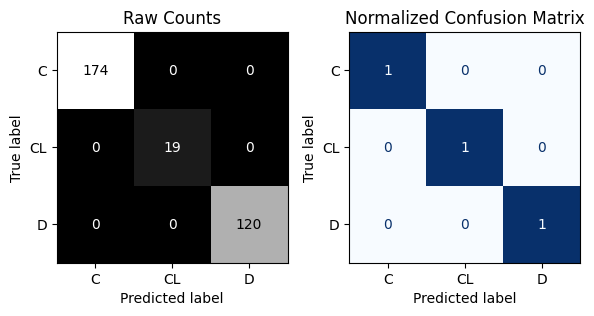


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           C       0.70      0.83      0.76        58
          CL       0.00      0.00      0.00         6
           D       0.69      0.61      0.65        41

    accuracy                           0.70       105
   macro avg       0.46      0.48      0.47       105
weighted avg       0.66      0.70      0.67       105



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


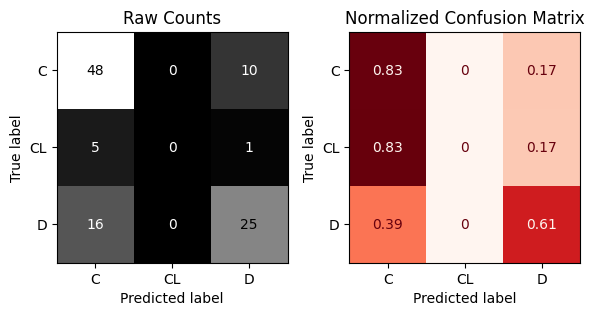

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [302]:
rf_final = RandomForestClassifier(random_state=42)
rf_final.fit(X_train_selected_mean, y_train)

evaluate_classification(rf_final, X_train_selected_mean, y_train, X_test_selected_mean, y_test)

#### Median Threshold

In [303]:
X_train_selected_median = selector_pipe_median.transform(X_train_combined)
X_test_selected_median = selector_pipe_median.transform(X_test_combined)

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           C       1.00      1.00      1.00       174
          CL       1.00      1.00      1.00        19
           D       1.00      1.00      1.00       120

    accuracy                           1.00       313
   macro avg       1.00      1.00      1.00       313
weighted avg       1.00      1.00      1.00       313



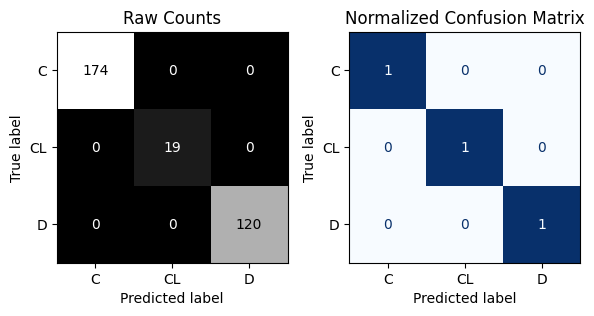


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           C       0.72      0.83      0.77        58
          CL       0.00      0.00      0.00         6
           D       0.68      0.63      0.66        41

    accuracy                           0.70       105
   macro avg       0.47      0.49      0.48       105
weighted avg       0.66      0.70      0.68       105



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


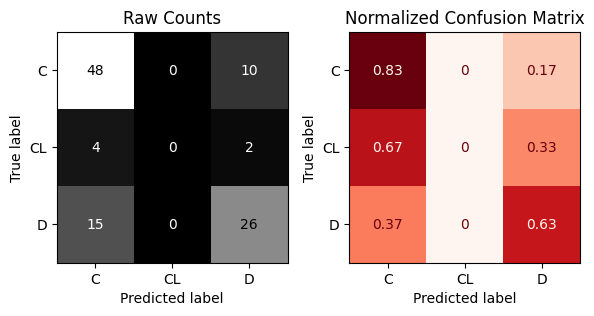

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [304]:
rf_final = RandomForestClassifier(random_state=42)
rf_final.fit(X_train_selected_median, y_train)

evaluate_classification(rf_final, X_train_selected_median, y_train, X_test_selected_median, y_test)

| **Model** | **Feature Engineering** | **Macro F1-Score** |
|:----------|:------------------------|:------------------:|
| Default | None | **0.49** |
| Engineered | PCA + Cluster | **0.50** |
| Selected Features | PCA + Cluster + SelectFromModel | **0.48** |

*Feature selection did not improve performance but the combined (PCA + Cluster) model without selection performed best*

> **Feature Selection Observations:**
>
> - I tried two thresholds for `SelectFromModel`: `'median'` and `'mean'`.
> - Both thresholds made the model **worse** than the combined (PCA + Cluster) model.
> - `'median'` threshold: test Macro F1 = 0.48
> - `'mean'` threshold: test Macro F1 = 0.47 (even worse)
> - The stricter the threshold (fewer features kept), the worse the model performed.
> - `CL` stayed at 0.00 F1 in every version, since feature selection cannot fix class imbalance.
> - This shows the issue isn't too many features but it's not enough training data . Removing features just removes useful information instead of removing noise.
> - Based on this, the **combined (PCA + Cluster) model without feature selection** is my best performing model, with a test Macro F1 of 0.50.

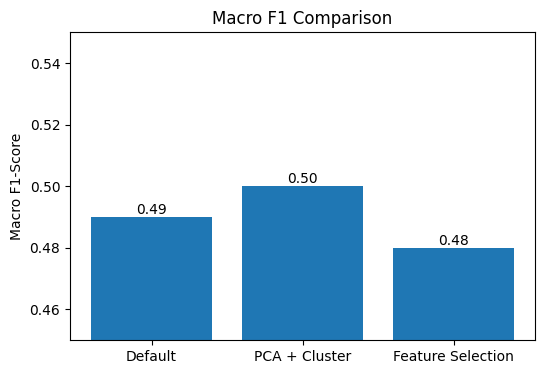

In [305]:
models = ["Default", "PCA + Cluster", "Feature Selection"]
scores = [0.49, 0.50, 0.48]

plt.figure(figsize=(6,4))
plt.bar(models, scores)

for i, score in enumerate(scores):
    plt.text(i, score + 0.001, f"{score:.2f}", ha='center')

plt.ylim(0.45, 0.55)
plt.title("Macro F1 Comparison")
plt.ylabel("Macro F1-Score");

### Permutation Importance: Top 10 Features (Final Model)

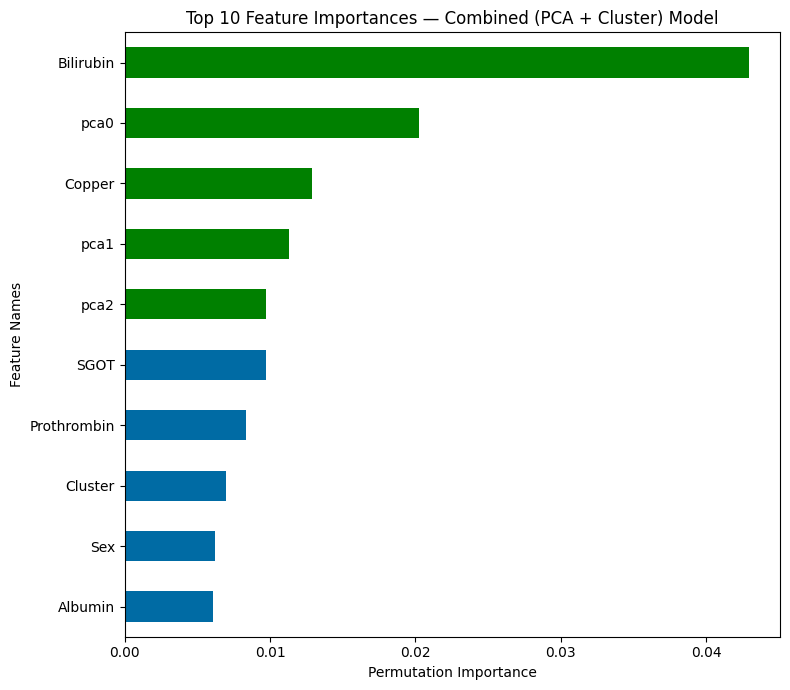

In [306]:
r_final = permutation_importance(
    rf_combined_pipe,
    X_test_combined,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro',
    n_jobs=-1
)

perm_importances_final = pd.Series(
    r_final['importances_mean'],
    index=X_test_combined.columns,
    name='Permutation Importance'
).sort_values(ascending=False)

colors_top5_final = get_color_dict(perm_importances_final, top_n=5)

ax = plot_importance_color(
    perm_importances_final,
    color_dict=colors_top5_final,
    top_n=10,
    figsize=(8, 7)
)
ax.set_xlabel("Permutation Importance")
ax.set_title("Top 10 Feature Importances — Combined (PCA + Cluster) Model")
plt.tight_layout()

> **Note on Permutation Importance vs. Actual Performance Gain:**
>
> - Interestingly, `pca0` ranks very high in permutation importance (2nd overall), but PCA alone did not improve the Macro F1-score earlier. This is because permutation importance shows how much the model *relies* on a
> feature, not how much *new* information it adds. Since `pca0` is a linear combination of already important original features (like Bilirubin and Copper), the model uses it often in splits, but it's redundant with information already available in the data so removing it doesn't hurt performance much.
>
> - `Cluster`, on the other hand, ranks lower in permutation importance but was the feature that actually improved Macro F1 (0.49 to 0.50). This suggests `Cluster` adds a small amount of genuinely new, non redundant information, even though the model doesn't lean on it as heavily as it leans on `pca0`.

> **Permutation Importance: Combined Model vs. Baseline**
>
> - `Bilirubin` is still the most important feature by far in both models, this did not change.
> - `Copper`, `Prothrombin`, and `Albumin` stayed in the top 10 in both models.
> - **New in the top 10:** all three PCA components (`pca0`, `pca1`, `pca2`) now appear, with `pca0` ranking **2nd**.
> - The `Cluster` feature also appears (rank 8).
> - **Dropped out:** `Ascites`, which was a top feature in default, is no longer in the top 10.
> - permutation importance shows the engineered features (especially `pca0`) are clearly influential in the model's decisions.
> - This suggests the PCA components captured some of the same signal as `Ascites` and other original features, essentially replacing them in importance without changing the overall prediction quality much.